# Unemployment Trends Analysis in India

#Objective:
To analyze unemployment patterns across Indian states and understand trends based on time, region, and urban/rural distribution.

###Import Libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

###Load Dataset

In [3]:
df = pd.read_csv("Unemployment in India.csv")

###Data Understanding



In [4]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [6]:
df.shape

(768, 7)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [8]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [9]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [10]:
df.describe(include=object)


,Region,Date,Frequency,Area
count,740,740,740,740
unique,28,14,2,2
top,Andhra Pradesh,31-10-2019,Monthly,Urban
freq,28,55,381,381


In [12]:
df.isnull().sum()


,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


###Data Preprocessing

In [13]:
df.columns = df.columns.str.strip()

In [15]:
df["Date"]= pd.to_datetime(df["Date"])

/tmp/ipykernel_378/2122934370.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date"]= pd.to_datetime(df["Date"])


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Region                     740 non-null    object        
 1   Date                       740 non-null    datetime64[ns]
 2   Frequency                  740 non-null    object        
 3   Unemployment_Rate          740 non-null    float64       
 4   Employed                   740 non-null    float64       
 5   Labour_Participation_Rate  740 non-null    float64       
 6   Area                       740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 42.1+ KB


###Data Cleaning

In [18]:
df.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Unemployment_Rate,28
Employed,28
Labour_Participation_Rate,28
Area,28


In [19]:
df.dropna(inplace=True)

In [20]:
df.isnull().sum()

,0
Region,0
Date,0
Frequency,0
Unemployment_Rate,0
Employed,0
Labour_Participation_Rate,0
Area,0


In [21]:
df.drop_duplicates(inplace=True)

Feature Engineering

In [23]:
df["Year"]= df["Date"].dt.year

In [24]:
df["Month"]=df["Date"].dt.month_name()

In [25]:
df["Quarter"]=df["Date"].dt.quarter

###Exploratory Data Analysis (EDA)

Overall Unemployment Trend

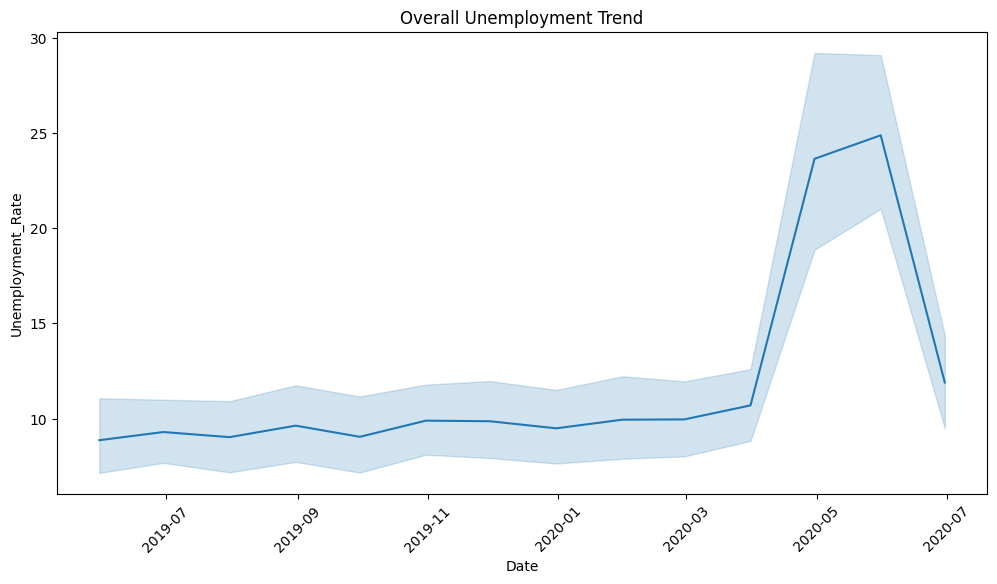

In [31]:
plt.figure(figsize=(12,6))

sns.lineplot(
    x = "Date",
    y = "Unemployment_Rate",
    data = df
)

plt.title("Overall Unemployment Trend")
plt.xticks(rotation=45)
plt.show()

State-Wise Avergae Unemployment

In [33]:
state_avg = df.groupby("Region")["Unemployment_Rate"].mean().sort_values(ascending=
                                                                       False)

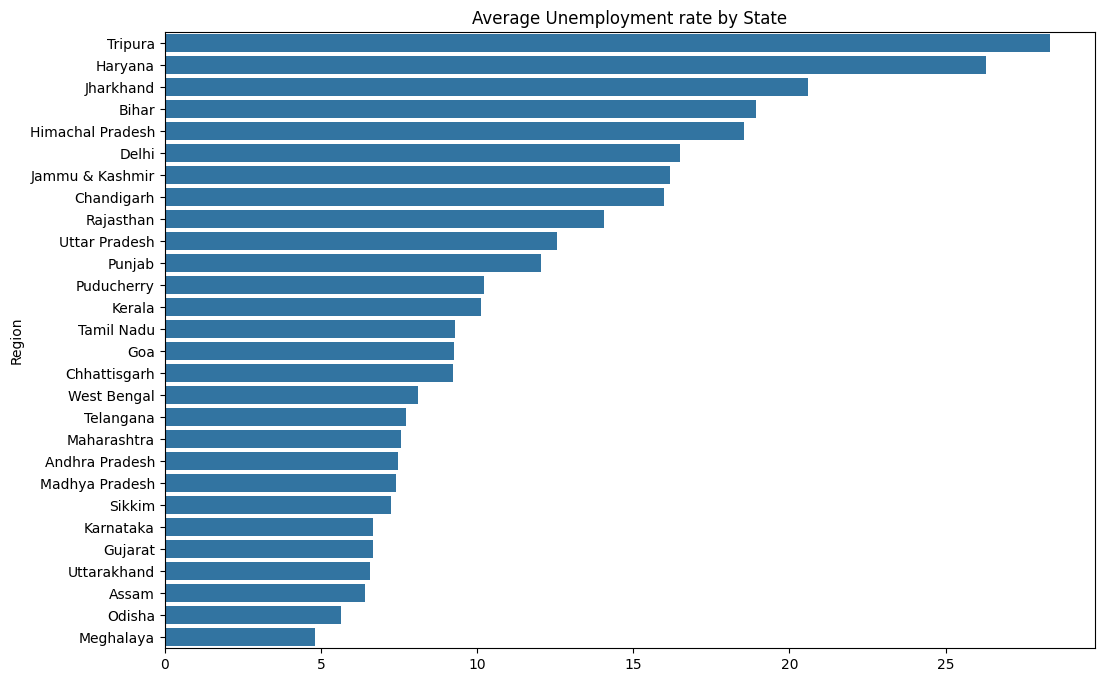

In [35]:
plt.figure(figsize=(12,8))

sns.barplot(
    x=state_avg.values,
    y=state_avg.index
)
plt.title("Average Unemployment rate by State")
plt.show()

Rural VS Urban Comparison

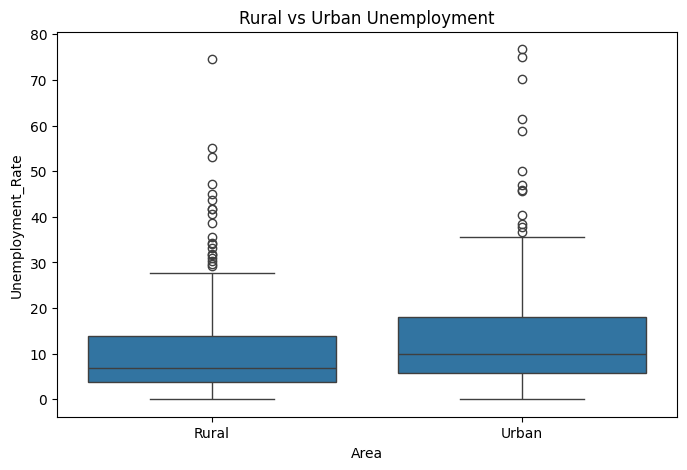

In [36]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Area",
    y="Unemployment_Rate",
    data=df

)
plt.title("Rural vs Urban Unemployment")
plt.show()

Covid Impact Analysis

In [38]:
covid = df[df["Date"] >= "2020-03-01"]

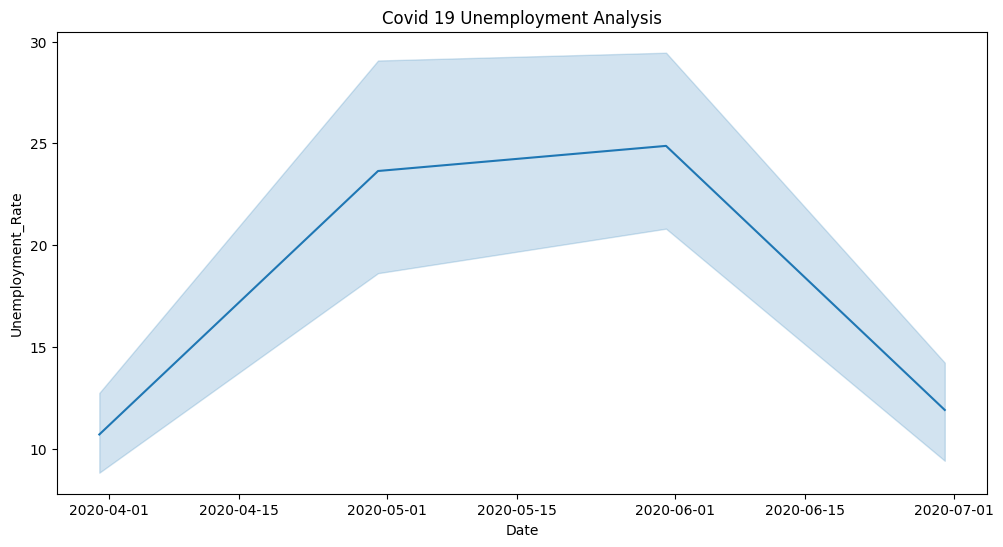

In [39]:
plt.figure(figsize=(12,6))

sns.lineplot(
    x ="Date",
    y ="Unemployment_Rate",
    data=covid
)
plt.title("Covid 19 Unemployment Analysis")
plt.show()

Top 10 States with Highest Unemployment


In [40]:
top10= state_avg.head(10)

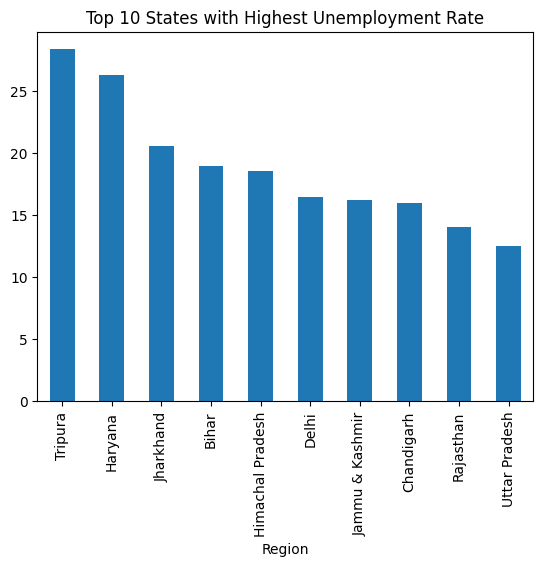

In [41]:
top10.plot(kind="bar")
plt.title("Top 10 States with Highest Unemployment Rate")
plt.show()

Correlation Heatmap

In [45]:
corr = df[[
    "Unemployment_Rate",
    "Employed",
    "Labour_Participation_Rate"
]].corr()

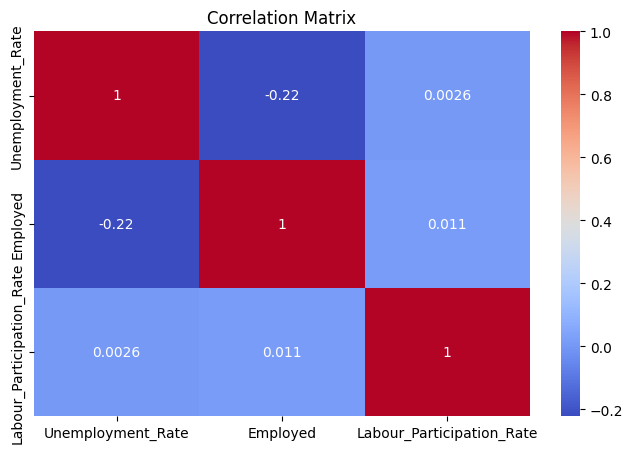

In [46]:
plt.figure(figsize=(8,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

Statistical Analysis

In [47]:
df.groupby("Region")[
    "Unemployment_Rate"
].mean()

,Unemployment_Rate
Region,
Andhra Pradesh,7.477143
Assam,6.428077
Bihar,18.918214
Chandigarh,15.991667
Chhattisgarh,9.240357
Delhi,16.495357
Goa,9.274167
Gujarat,6.663929
Haryana,26.283214


In [48]:
df.groupby("Area").agg({
    "Unemployment_Rate":"mean",
    "Employed":"mean"
})

,Unemployment_Rate,Employed
Area,,
Rural,10.324791,1.019285e+07
Urban,13.166614,4.388626e+06


In [50]:
pivot = pd.pivot_table(
    df,
    values="Unemployment_Rate",
    index="Region",
    columns="Area"
)

# Insights

- Unemployment increased sharply during COVID-19.
- Some states consistently recorded higher unemployment rates.
- Urban regions showed stronger unemployment fluctuations.
- Labour participation and employment are positively correlated.
- Certain regions recovered faster after pandemic periods.

# Conclusion

This project analyzed unemployment trends across India using data preprocessing, feature engineering, visualization, and statistical analysis. The analysis identified regional unemployment differences, COVID-19 impacts, and labour participation trends.